## Project Objective

The goal of this analysis is to understand user behavior on a large-scale e-commerce platform by analyzing event-level interaction data. The project focuses on identifying funnel drop-offs, retention patterns, and distinct user segments to derive actionable product insights.


In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## Data Loading & Sampling Strategy

Due to the scale of the raw dataset (~285M events), a representative sample of 5–10M events was used for analysis to enable efficient exploration while preserving behavioral patterns.


In [3]:
df = pd.read_csv("/kaggle/input/ecommerce-behavior-data-from-multi-category-store/2019-Nov.csv", 
                usecols=['event_time','event_type','product_id','category_code','price','user_id'],
                chunksize = 1_000_000)
df_list = []
for i, chunk in enumerate(df):
    df_list.append(chunk)
    if i == 4:
        break
df = pd.concat(df_list, ignore_index = True)

,event_time,event_type,product_id,category_code,price,user_id
0,2019-11-01 00:00:00 UTC,view,1003461,electronics.smartphone,489.07,520088904
1,2019-11-01 00:00:00 UTC,view,5000088,appliances.sewing_machine,293.65,530496790
2,2019-11-01 00:00:01 UTC,view,17302664,NaN,28.31,561587266
3,2019-11-01 00:00:01 UTC,view,3601530,appliances.kitchen.washer,712.87,518085591
4,2019-11-01 00:00:01 UTC,view,1004775,electronics.smartphone,183.27,558856683


In [4]:
df['event_time'] = pd.to_datetime(df['event_time'])
df['date'] = df['event_time'].dt.date
df = df[df['price']>=0]
df['event_type'].value_counts()

event_type
view        4862128
purchase      73778
cart          64094
Name: count, dtype: int64

count of the following events: view 4862128 purchase 73778 cart 64094

In [5]:
df.shape
df['user_id'].nunique()
df['product_id'].nunique()
df['event_type'].value_counts(normalize=True)

event_type
view        0.972426
purchase    0.014756
cart        0.012819
Name: proportion, dtype: float64

shape of the database is 5000000, 7 which means that we are sampling 5 million rows of data over 7 columns 

number of unique users = 643539 

number of unique products = 114030 

proportion of VIEW, PURCHASE, CART events = 

view 0.972426 

purchase 0.014756 

cart 0.012819

In [6]:
df["event_type"] = df["event_type"].astype("category")
df["category_code"] = df["category_code"].astype("category")
df.to_parquet = 'clean_events.parquet'

## Exploratory Data Analysis (EDA)

This section explores overall platform usage patterns, event distribution, and user activity trends to establish a baseline understanding of user behavior.


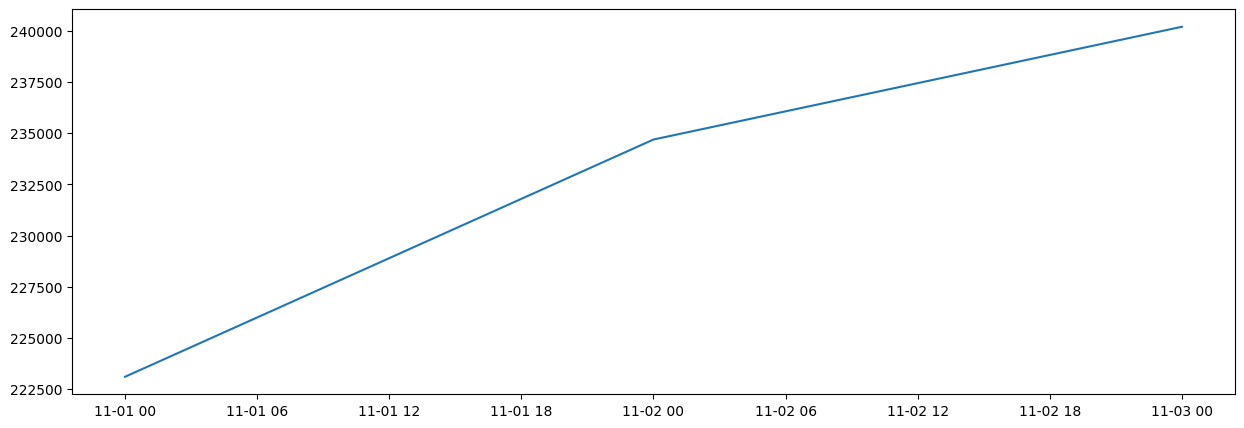

In [7]:
max_date = df["date"].max()
df = df[df['date']!=max_date]
unique_user = df.groupby("date")["user_id"].nunique()
plt.figure(figsize=(15, 5))
plt.plot(unique_user)

### Daily Active Users (DAU)

This plot helps evaluate short-term user engagement trends and identify potential anomalies caused by sampling or incomplete data coverage.


A sharp drop in DAU was observed on the last date in the sample. This was identified as a data sampling artifact caused by chunk-based loading of the first 5M rows, resulting in incomplete coverage for the final day. Partial-day data was excluded from trend analysis to avoid misleading interpretations.


After excluding the partially ingested final day, DAU was analyzed over a 3-day window (Nov 1–Nov 3). The number of unique active users shows a gradual increase across these days, indicating stable short-term engagement. However, due to the limited temporal coverage of the sampled data, no long-term growth conclusions were drawn.


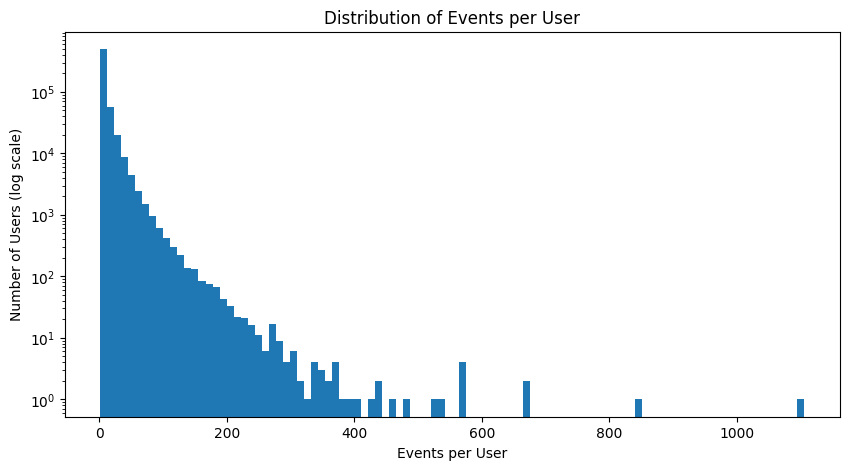

In [8]:
events_per_user = df.groupby("user_id").size()
plt.figure(figsize=(10,5))
plt.hist(events_per_user, bins=100)
plt.yscale("log")
plt.xlabel("Events per User")
plt.ylabel("Number of Users (log scale)")
plt.title("Distribution of Events per User")
plt.show()


### Events per User Distribution

This distribution highlights the presence of long-tail behavior, distinguishing casual users from a small subset of highly active users.


The distribution of events per user is highly right-skewed. Most users perform only a small number of events before disengaging, indicating predominantly casual usage. However, a small subset of users exhibits very high activity levels, forming a long tail of power users who contribute disproportionately to overall platform interactions.


In [79]:
categoryplot = (df.groupby(["category_code", "event_type"]).size().unstack(fill_value=0))
categoryplot["proxy_conv"] = (categoryplot["purchase"] / categoryplot["view"])
categoryplot = categoryplot[categoryplot["view"] > 1000]
top_10_category = categoryplot.sort_values("proxy_conv", ascending=False).head(10)

/tmp/ipykernel_106/1535406028.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  categoryplot = (df.groupby(["category_code", "event_type"]).size().unstack(fill_value=0))


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


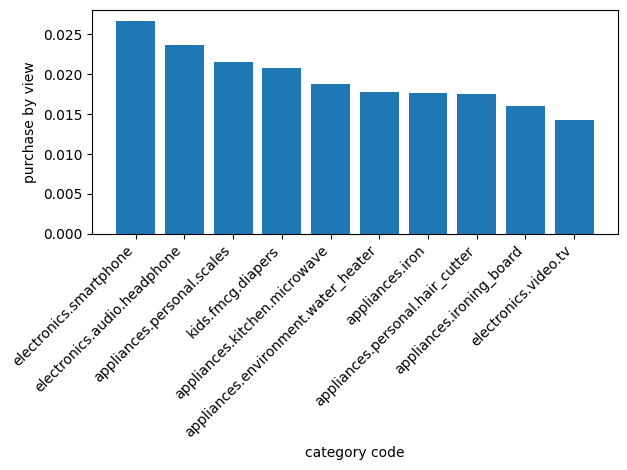

In [10]:
plt.figure()
plt.bar(top_10_category.index, top_10_category["proxy_conv"])
plt.xlabel("category code")
plt.ylabel("purchase by view")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Category-Level Conversion (Purchase / View)

Across categories, purchase-to-view conversion rates are relatively low (approximately 1.6%–2.7%), indicating that the majority of users engage primarily in browsing behavior. Electronics and essential goods exhibit slightly higher conversion rates, suggesting stronger purchase intent in these categories. Since this metric does not account for add-to-cart events, further funnel analysis is required to identify whether drop-offs occur before or after cart interaction.


## Funnel Analysis (View → Cart → Purchase)

This section analyzes how users progress through the product discovery and purchase funnel, identifying key drop-off points and conversion behavior.


In [11]:
funnel_users = (
    df.groupby("event_type")["user_id"]
      .nunique()
      .reindex(["view", "cart", "purchase"]))

/tmp/ipykernel_106/3796531049.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("event_type")["user_id"]


event_type
view        591595
cart         29753
purchase     44873
Name: user_id, dtype: int64

In [12]:
funnel_df = funnel_users.to_frame(name="users")
funnel_df["conversion_from_previous"] = (
    funnel_df["users"] / funnel_df["users"].shift(1)
)

funnel_df.head()


,users,conversion_from_previous
event_type,,
view,591595,NaN
cart,29753,0.050293
purchase,44873,1.508184


### Funnel Analysis (View → Cart → Purchase)

Out of 591,595 users who viewed products, only 29,753 users (5.03%) added items to the cart, indicating a substantial drop-off at the top of the funnel. Interestingly, the number of purchasing users (44,873) exceeds cart users, suggesting that a significant portion of purchases occur without recorded cart events. This may be due to direct checkout functionality, cross-session behavior, or incomplete cart event logging. As a result, the primary friction point appears to be before cart interaction rather than during checkout.


In [13]:
view_users = set(df[df["event_type"] == "view"]["user_id"])
cart_users = set(df[df["event_type"] == "cart"]["user_id"])
purchase_users = set(df[df["event_type"] == "purchase"]["user_id"])

direct_purchase_users = purchase_users - cart_users
len(direct_purchase_users)
len(direct_purchase_users) / len(purchase_users)

0.609185924720879

### Direct Purchase Behavior

Approximately 60.9% of purchasing users completed transactions without a recorded cart event. This suggests that direct checkout plays a significant role in the platform’s purchase flow, and that the cart stage is not a mandatory step for conversion. Funnel analysis was therefore interpreted with the understanding that view-to-purchase paths may bypass the cart stage.


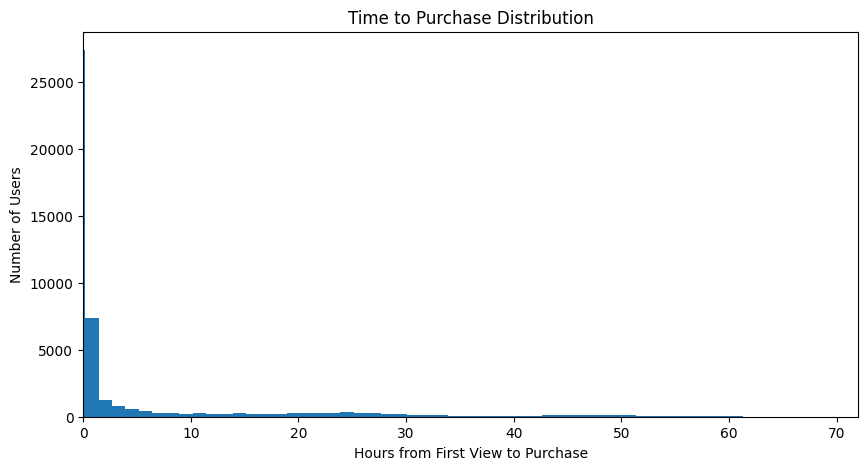

In [14]:
user_times = df.sort_values("event_time")

first_view = (
    user_times[user_times["event_type"] == "view"]
    .groupby("user_id")["event_time"]
    .first()
)

first_purchase = (
    user_times[user_times["event_type"] == "purchase"]
    .groupby("user_id")["event_time"]
    .first()
)

time_to_purchase = (
    first_purchase - first_view
).dropna().dt.total_seconds() / 3600  # hours


plt.figure(figsize=(10,5))
plt.hist(time_to_purchase, bins=100)
plt.xlim(0, 72)
plt.xlabel("Hours from First View to Purchase")
plt.ylabel("Number of Users")
plt.title("Time to Purchase Distribution")
plt.show()


### Time to Purchase Analysis

The time-to-purchase distribution is heavily right-skewed, with a large concentration of users completing purchases within the first few hours after their initial product view. This suggests strong impulse or high-intent buying behavior. A long tail is also observed, indicating that a smaller subset of users takes significantly longer to convert, likely due to comparison shopping or delayed decision-making.


## Retention & Cohort Analysis

Cohort-based retention analysis is used to understand how user engagement evolves after the first interaction and to quantify early churn behavior.


In [15]:
cohort_date = df.groupby("user_id")['event_time'].min()
cohort_date.head()
df = df.merge(
    cohort_date.rename("cohort_date"),
    on = 'user_id',
    how ="left"
)
df['cohort_date'] = pd.to_datetime(df['cohort_date'])
df['cohort_date'] = df['cohort_date'].dt.date

In [16]:
df['cohort_day'] = df['date'] - df['cohort_date']
cohort_user = (df.groupby(["cohort_date", "cohort_day"])["user_id"]
               .nunique()
               .unstack(fill_value=0)
               )

cohort_day,0 days,1 days,2 days
cohort_date,,,
2019-11-01,223108,41734,34691
2019-11-02,192951,29927,0
2019-11-03,175569,0,0


In [17]:
cohort_normal = cohort_user.div(cohort_user['0 days'], axis=0)
cohort_normal = cohort_normal.multiply(100, axis=0)
cohort_normal.head()

cohort_day,0 days,1 days,2 days
cohort_date,,,
2019-11-01,100.0,18.705739,15.548972
2019-11-02,100.0,15.510155,0.000000
2019-11-03,100.0,0.000000,0.000000


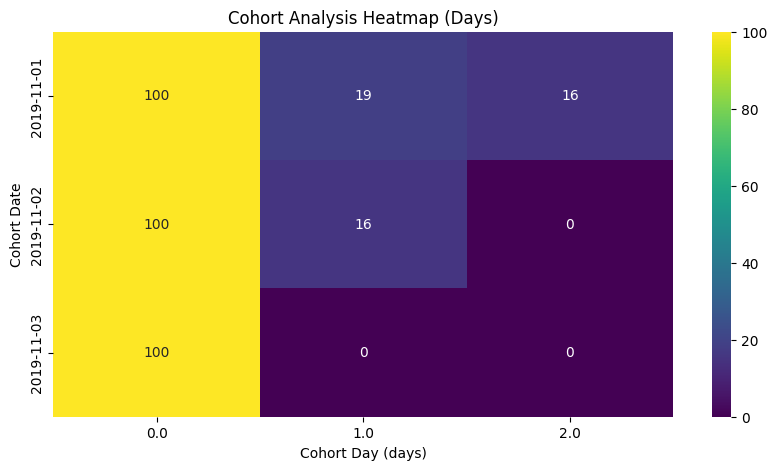

In [18]:
cohort_normal_hmap = cohort_normal.copy()
cohort_normal_hmap.columns = cohort_normal_hmap.columns / np.timedelta64(1, 'D')  # convert columns to days

plt.figure(figsize=(10,5))
sns.heatmap(cohort_normal_hmap, cmap='viridis', annot=True, fmt='.0f')
plt.title('Cohort Analysis Heatmap (Days)')
plt.ylabel('Cohort Date')
plt.xlabel('Cohort Day (days)')
plt.show()


## User Segmentation

Event-level data is aggregated into a user-level feature table to identify distinct behavioral segments using unsupervised clustering.


In [35]:
user_table = (
    df.groupby(["user_id", "event_type"])
      .size()
      .unstack(fill_value=0)
      .reset_index()
)
user_table['purchase_ratio'] = (
    user_table['purchase'] /
    user_table['view'].replace(0, np.nan)
).fillna(0)

user_table = user_table.merge(active_days, on='user_id')

/tmp/ipykernel_106/4129909213.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["user_id", "event_type"])


,user_id,cart,purchase,view,purchase_ratio,active_days
0,216064734,0,0,1,0.0,1
1,245978545,0,0,2,0.0,1
2,249991351,0,0,1,0.0,1
3,253624608,0,0,2,0.0,1
4,260013793,0,0,17,0.0,1


In [61]:
X = user_table.drop(columns=['user_id'])
X_scaled = StandardScaler().fit_transform(X)
scaler = StandardScaler(copy=True, with_mean=True, with_std=True)
kmeans = KMeans(n_clusters=4)
labels = kmeans.fit_predict(X_scaled)
centroids = kmeans.cluster_centers_
user_table['cluster'] = labels
user_table['cluster'].value_counts().sort_index()

cluster
0     66640
1    496893
2     25434
3      2661
Name: count, dtype: int64

In [78]:
cluster_summary = (
    user_table
    .groupby('cluster')
    .agg(
        mean_view=('view', 'mean'),
        mean_cart=('cart', 'mean'),
        mean_purchase=('purchase', 'mean'),
        mean_purchase_ratio=('purchase_ratio', 'mean'),
        mean_active_days=('active_days', 'mean'),
        users=('user_id', 'count')
    )
    .reset_index()
)

cluster_summary

,cluster,mean_view,mean_cart,mean_purchase,mean_purchase_ratio,mean_active_days,users
0,0,31.216672,0.145918,0.196744,0.008745,1.945228,66640
1,1,4.357135,0.025837,0.013949,0.001495,1.073746,496893
2,2,5.048400,0.712747,1.422623,0.413643,1.184202,25434
3,3,26.314543,6.682450,3.848929,0.200317,1.763998,2661


## User Segmentation Analysis

To understand heterogeneity in user behavior, event-level logs were aggregated into a user-level feature table capturing browsing, purchase, and engagement patterns. Features included total views, cart additions, purchases, purchase-to-view ratio, and number of active days. These features were standardized and clustered using K-Means to identify distinct behavioral segments.

### Identified User Segments

| Segment | Users | Key Characteristics |
|------|------|---------------------|
| Casual Browsers | ~497k | Low activity users with few views, almost no cart additions or purchases, and minimal return behavior. |
| Window Shoppers | ~67k | Heavy browsing users with high view counts but very low conversion, suggesting comparison or research-oriented behavior. |
| Impulse Buyers | ~25k | High purchase efficiency with few views, frequent direct purchases, and limited session depth. |
| Power Users | ~2.6k | Highly engaged users with extensive browsing, frequent cart usage, multiple purchases, and repeat activity. |

### Key Insights

- The majority of users belong to low-engagement segmentsS, exhibiting browsing-heavy behavior and high early churn.
- A small but distinct segment of impulse buyers demonstrates high purchase efficiency, often converting within a single session.
- Power users form a very small fraction of the user base but exhibit disproportionately high engagement and transactional activity.
- Window shoppers represent a unique segment with high exploratory behavior but low conversion, indicating potential opportunities for targeted pricing, recommendations, or nudges.

Overall, segmentation results align with earlier funnel and retention analyses, reinforcing the presence of strong early churn, direct-purchase behavior, and a long-tail distribution of highly engaged users.


## Final Summary & Key Takeaways

This analysis examined large-scale e-commerce user interaction data to understand behavioral patterns across browsing, purchasing, and retention stages.

Key findings include:
- User behavior is heavily browsing-driven, with the majority of interactions being product views and significant drop-off before purchase.
- Approximately 60% of purchases bypass the cart stage, indicating strong direct-purchase or high-intent buying behavior.
- Cohort analysis reveals sharp Day-1 churn, followed by stabilization among a small subset of returning users.
- User segmentation identifies four distinct behavioral groups: casual browsers, window shoppers, impulse buyers, and power users.
- A very small fraction of power users accounts for disproportionately high engagement and purchasing activity.

Overall, the results suggest that improving early retention and optimizing high-intent purchase flows could significantly impact platform performance.